In [23]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import ClassifierChain
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, multilabel_confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
#from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
def filter_rare_classes(y, min_samples=5):
    column_sums = y.sum(axis=0)
    valid_columns = column_sums >= min_samples
    return y[:, valid_columns], valid_columns

In [25]:

df = pd.read_csv("patient.csv", encoding="utf-8", low_memory=False)
df.columns = [col.strip() for col in df.columns]
df = df.drop(columns=["Birthdate", "ID"])
df["Malnutrition Type"] = df["Malnutrition Type"].apply(lambda x: [s.strip() for s in re.split('[,و]', str(x))] if pd.notna(x) else [])

In [26]:
#تبدیل مقادیر چندمین فرزند به عدد
df["Birth Order"].replace("3-3قلو","33", inplace=True)
df["Birth Order"].replace("دوقلو","22", inplace=True)
df["Birth Order"].replace("چهارقلو","44", inplace=True)
df["Birth Order"].replace("nan",np.nan,inplace=True)
df["Birth Order"] = pd.to_numeric(df["Birth Order"], errors='coerce').astype('Int64')
df["Birth Order"].unique()

<IntegerArray>
[2, 1, 4, 3, 5, 33, <NA>, 6, 44, 22]
Length: 10, dtype: Int64

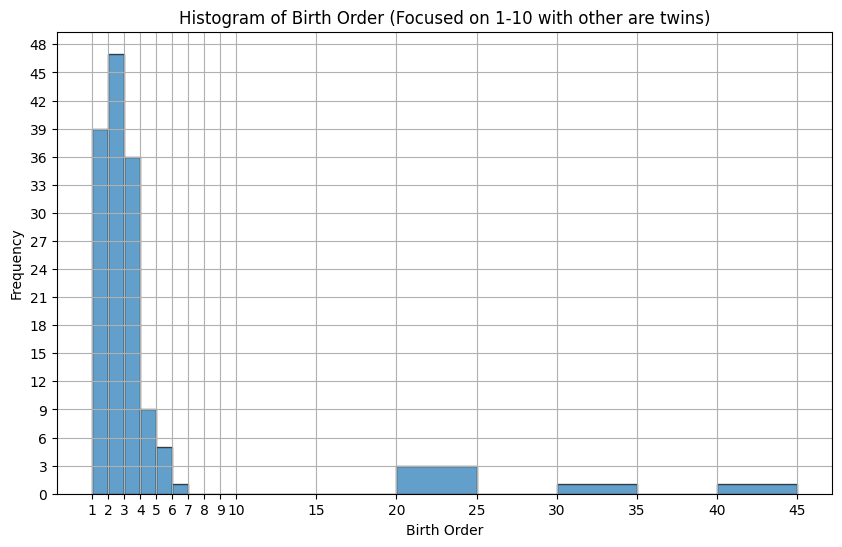

In [27]:
# نمایش هستوگرام چندمین فرزند
bins = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45]


plt.figure(figsize=(10, 6))
df["Birth Order"].hist(bins=bins, edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on 1-10 with other are twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(bins)
max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()

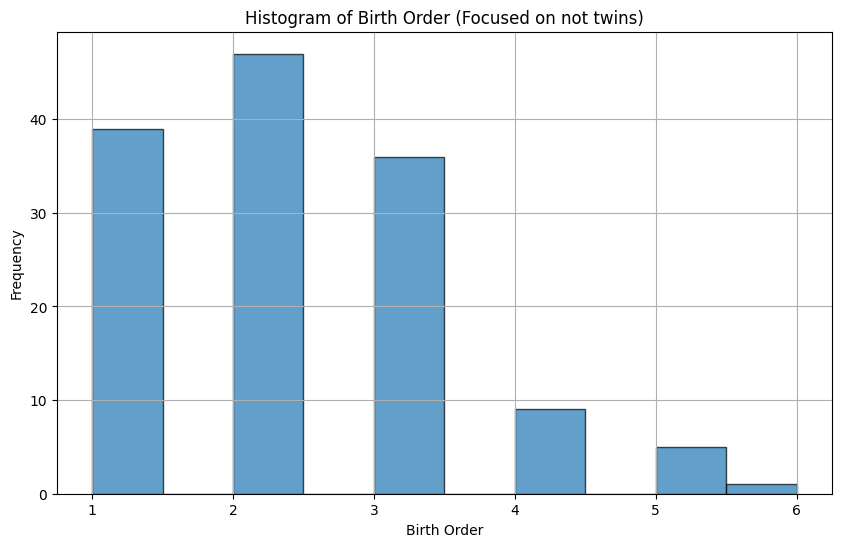

In [28]:
#هستوگرام بدون در نظر گرفتن چند قلو ها
plt.figure(figsize=(10, 6))
df["Birth Order"].where(df["Birth Order"]<10).hist(edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on not twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
# plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()

In [29]:
# Handle multi-label target
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["Malnutrition Type"])
X = df.drop(columns=["Malnutrition Type"])

In [30]:
# Filter rare classes
y, valid_cols = filter_rare_classes(y, min_samples=2)
if y.shape[1] == 0:
    raise ValueError("No classes with sufficient samples after filtering.")
class_names = mlb.classes_[valid_cols]

In [31]:
# Remove samples with no remaining labels
has_labels = y.sum(axis=1) > 0
X = X[has_labels].reset_index(drop=True)
y = y[has_labels]

In [32]:
print(df.isna().sum())

Gender                                     1048433
Age                                        1048433
Birth Order                                1048433
Mother's Age at Pregnancy (Years)          1048433
Abortion History                           1048435
Type of Delivery                           1048476
Mother Underweight (BMI < 18.5)            1048433
Pressure                                   1048457
Blood Pressure (Week 24-30) - Systolic     1048507
Blood Pressure (Week 24-30) - Diastolic    1048507
Blood Pressure (Week 31-34) - Systolic     1048514
Blood Pressure (Week 31-34) - Diastolic    1048514
Blood Pressure (Week 36-37) - Systolic     1048520
Blood Pressure (Week 36-37) - Diastolic    1048521
Pregnancy Weeks                            1048478
Gestational Diabetes                       1048434
Diabetes (Week 6-10)                       1048548
Diabetes (Week 24-30)                      1048551
Developmental Issues (2 Months)            1048433
Developmental Issues (9 Months)

In [33]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])
df['Birth Order'] = df['Birth Order'].fillna(df['Birth Order'].mode()[0])
#df["Mother's Age at Pregnancy (Years)"] = pd.to_numeric(df["Mother's Age at Pregnancy (Years)"], errors='coerce').astype('Int64')
#df["Mother's Age at Pregnancy (Years)"] = df["Mother's Age at Pregnancy (Years)"].fillna(df["Mother's Age at Pregnancy (Years)"].mode()[0])
df["Abortion History"] = df["Abortion History"].fillna(df["Abortion History"].mode()[0])
df["Type of Delivery"] = df["Type of Delivery"].fillna(df["Type of Delivery"].mode()[0])
df["Mother Underweight (BMI < 18.5)"] = df["Mother Underweight (BMI < 18.5)"].fillna(df["Mother Underweight (BMI < 18.5)"].mode()[0])
df["Pressure"] = df["Pressure"].fillna(df["Pressure"].mode()[0])
df["Blood Pressure (Week 24-30) - Systolic"] = df["Blood Pressure (Week 24-30) - Systolic"].fillna(df["Blood Pressure (Week 24-30) - Systolic"].mode()[0])
df["Blood Pressure (Week 24-30) - Diastolic"] = df["Blood Pressure (Week 24-30) - Diastolic"].fillna(df["Blood Pressure (Week 24-30) - Diastolic"].mode()[0])
df["Blood Pressure (Week 31-34) - Systolic"] = df["Blood Pressure (Week 31-34) - Systolic"].fillna(df["Blood Pressure (Week 31-34) - Systolic"].mode()[0])
df["Blood Pressure (Week 31-34) - Diastolic"] = df["Blood Pressure (Week 31-34) - Diastolic"].fillna(df["Blood Pressure (Week 31-34) - Diastolic"].mode()[0])
df["Blood Pressure (Week 36-37) - Systolic"] = df["Blood Pressure (Week 36-37) - Systolic"].fillna(df["Blood Pressure (Week 36-37) - Systolic"].mode()[0])
df["Blood Pressure (Week 36-37) - Diastolic"] = df["Blood Pressure (Week 36-37) - Diastolic"].fillna(df["Blood Pressure (Week 36-37) - Diastolic"].mode()[0])
#df["Pregnancy Weeks"] = pd.to_numeric(df["Pregnancy Weeks"], errors='coerce').astype('Int64')
#df['Pregnancy Weeks'] = df['Pregnancy Weeks'].fillna(df['Pregnancy Weeks'].mode()[0])
#df['Gestational Diabetes'] = df['Gestational Diabetes'].fillna(df['Gestational Diabetes'].mode()[0])
df['Diabetes (Week 6-10)'] = df['Diabetes (Week 6-10)'].fillna(df['Diabetes (Week 6-10)'].mode()[0])
df['Diabetes (Week 24-30)'] = df['Diabetes (Week 24-30)'].fillna(df['Diabetes (Week 24-30)'].mean())
df['Developmental Issues (2 Months)'] = df['Developmental Issues (2 Months)'].fillna(df['Developmental Issues (2 Months)'].mode()[0])
df['Developmental Issues (9 Months)'] = df['Developmental Issues (9 Months)'].fillna(df['Developmental Issues (9 Months)'].mode()[0])
df['Developmental Issues (18 Months)'] = df['Developmental Issues (18 Months)'].fillna(df['Developmental Issues (18 Months)'].mode()[0])
df['Breast Milk Sufficiency (3-5 Days)'] = df['Breast Milk Sufficiency (3-5 Days)'].fillna(df['Breast Milk Sufficiency (3-5 Days)'].mode()[0])
df["Head Circumference at Birth (cm)"] = pd.to_numeric(df["Head Circumference at Birth (cm)"], errors='coerce').astype('float64')
df['Head Circumference at Birth (cm)'] = df['Head Circumference at Birth (cm)'].fillna(df['Head Circumference at Birth (cm)'].mean())
df['Head Circumference (14-15 Days)'] = df['Head Circumference (14-15 Days)'].fillna(df['Head Circumference (14-15 Days)'].mean())
df['Head Circumference at 1 Year (cm)'] = df['Head Circumference at 1 Year (cm)'].fillna(df['Head Circumference at 1 Year (cm)'].mean())
df['Head Circumference Check (14-15 Days)'] = df['Head Circumference Check (14-15 Days)'].fillna(df['Head Circumference Check (14-15 Days)'].mean())
df['Head Circumference Check (1 Year)'] = df['Head Circumference Check (1 Year)'].fillna(df['Head Circumference Check (1 Year)'].mean())
df['Height at Birth (cm)'] = df['Height at Birth (cm)'].fillna(df['Height at Birth (cm)'].mean())
df['Height at 6 Months (cm)'] = df['Height at 6 Months (cm)'].fillna(df['Height at 6 Months (cm)'].mean())
df['Height at 12 Months (cm)'] = df['Height at 12 Months (cm)'].fillna(df['Height at 12 Months (cm)'].mean())
df['Height at 18 Months (cm)'] = df['Height at 18 Months (cm)'].fillna(df['Height at 18 Months (cm)'].mean())
df['Height at 2 Years (cm)'] = df['Height at 2 Years (cm)'].fillna(df['Height at 2 Years (cm)'].mean())
df['Height at 3 Years (cm)'] = df['Height at 3 Years (cm)'].fillna(df['Height at 3 Years (cm)'].mean())
df['Height at 4 Years (cm)'] = df['Height at 4 Years (cm)'].fillna(df['Height at 4 Years (cm)'].mean())
# df['Weight at Birth (kg)'] = df['Weight at Birth (kg)'].fillna(df['Weight at Birth (kg)'].mean())
df['Weight at 6 Months (kg)'] = df['Weight at 6 Months (kg)'].fillna(df['Weight at 6 Months (kg)'].mean())
df['Weight at 12 Months (kg)'] = df['Weight at 12 Months (kg)'].fillna(df['Weight at 12 Months (kg)'].mean())
df['Weight at 18 Months (kg)'] = df['Weight at 18 Months (kg)'].fillna(df['Weight at 18 Months (kg)'].mean())
df['Weight at 2 Years (kg)'] = df['Weight at 2 Years (kg)'].fillna(df['Weight at 2 Years (kg)'].mean())
df['Weight at 3 Years (kg)'] = df['Weight at 3 Years (kg)'].fillna(df['Weight at 3 Years (kg)'].mean())
df['Weight at 4 Years (kg)'] = df['Weight at 4 Years (kg)'].fillna(df['Weight at 4 Years (kg)'].mean())
df['Hypothyroidism (3-5 Days)'] = df['Hypothyroidism (3-5 Days)'].fillna(df['Hypothyroidism (3-5 Days)'].mode()[0])

In [34]:
print(df.isna().sum())

Gender                                           0
Age                                              0
Birth Order                                      0
Mother's Age at Pregnancy (Years)          1048433
Abortion History                                 0
Type of Delivery                                 0
Mother Underweight (BMI < 18.5)                  0
Pressure                                         0
Blood Pressure (Week 24-30) - Systolic           0
Blood Pressure (Week 24-30) - Diastolic          0
Blood Pressure (Week 31-34) - Systolic           0
Blood Pressure (Week 31-34) - Diastolic          0
Blood Pressure (Week 36-37) - Systolic           0
Blood Pressure (Week 36-37) - Diastolic          0
Pregnancy Weeks                            1048478
Gestational Diabetes                       1048434
Diabetes (Week 6-10)                             0
Diabetes (Week 24-30)                            0
Developmental Issues (2 Months)                  0
Developmental Issues (9 Months)

In [35]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Oversample minority classes (multi-label aware)
#ros = RandomOverSampler(random_state=42)
#X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)
X_train_resampled, y_train_resampled = X_train, y_train
# Build numeric transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X.select_dtypes(include=np.number).columns)
    ])

# XGBoost with balanced weight
base_estimator = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=1  # Let RandomOverSampler handle class balance
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ClassifierChain(base_estimator=base_estimator))
])

In [37]:
# Train model
pipeline.fit(X_train_resampled, y_train_resampled)

C:\Users\Win 10\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:36:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Gender', 'Age', 'Birth Order', 'Mother's Age at Pregnancy (Years)',
       'Abortion History', 'Type of Delivery',
       'Mother Underweight (BMI < 18.5)', 'Pressure',
       'Blood Pressure (Week 24-30) - Systolic',
       'Blood Pre...
                                                              feature_weights=None,
                                                              gamma=None,
                                                              grow_policy=None,
                                                              importance_type=None,
                                                              interaction_constraints=None,
                                                              learning_rate=None,
                                                              max_bin=None,
                                                              max_cat_threshold=None,
                                                              max_cat_to_onehot=None,
                                                              max_delta_step=None,
                                                              max_depth=None,
                                                              max_leaves=None,
                                                              min_child_weight=None,
                                                              missing=nan,
                                                              monotone_constraints=None,
                                                              multi_strategy=None,
                                                              n_estimators=None,
                                                              n_jobs=None,
                                                              num_parallel_tree=None, ...)))])

In [38]:
# Predict
y_pred = pipeline.predict(X_test)

In [39]:
# Evaluate
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
accuracy = (y_test == y_pred).mean()
print(f"\n🔍 Model Accuracy: {accuracy:.2f}")


📊 Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.80      0.53      0.64        15
           3       0.00      0.00      0.00         1
           4       0.62      0.93      0.74        14
           5       1.00      1.00      1.00         1
           6       0.55      0.50      0.52        12

   micro avg       0.62      0.64      0.63        44
   macro avg       0.49      0.49      0.48        44
weighted avg       0.64      0.64      0.62        44
 samples avg       0.61      0.65      0.61        44


🔍 Model Accuracy: 0.81


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



📉 Confusion Matrix for each class:


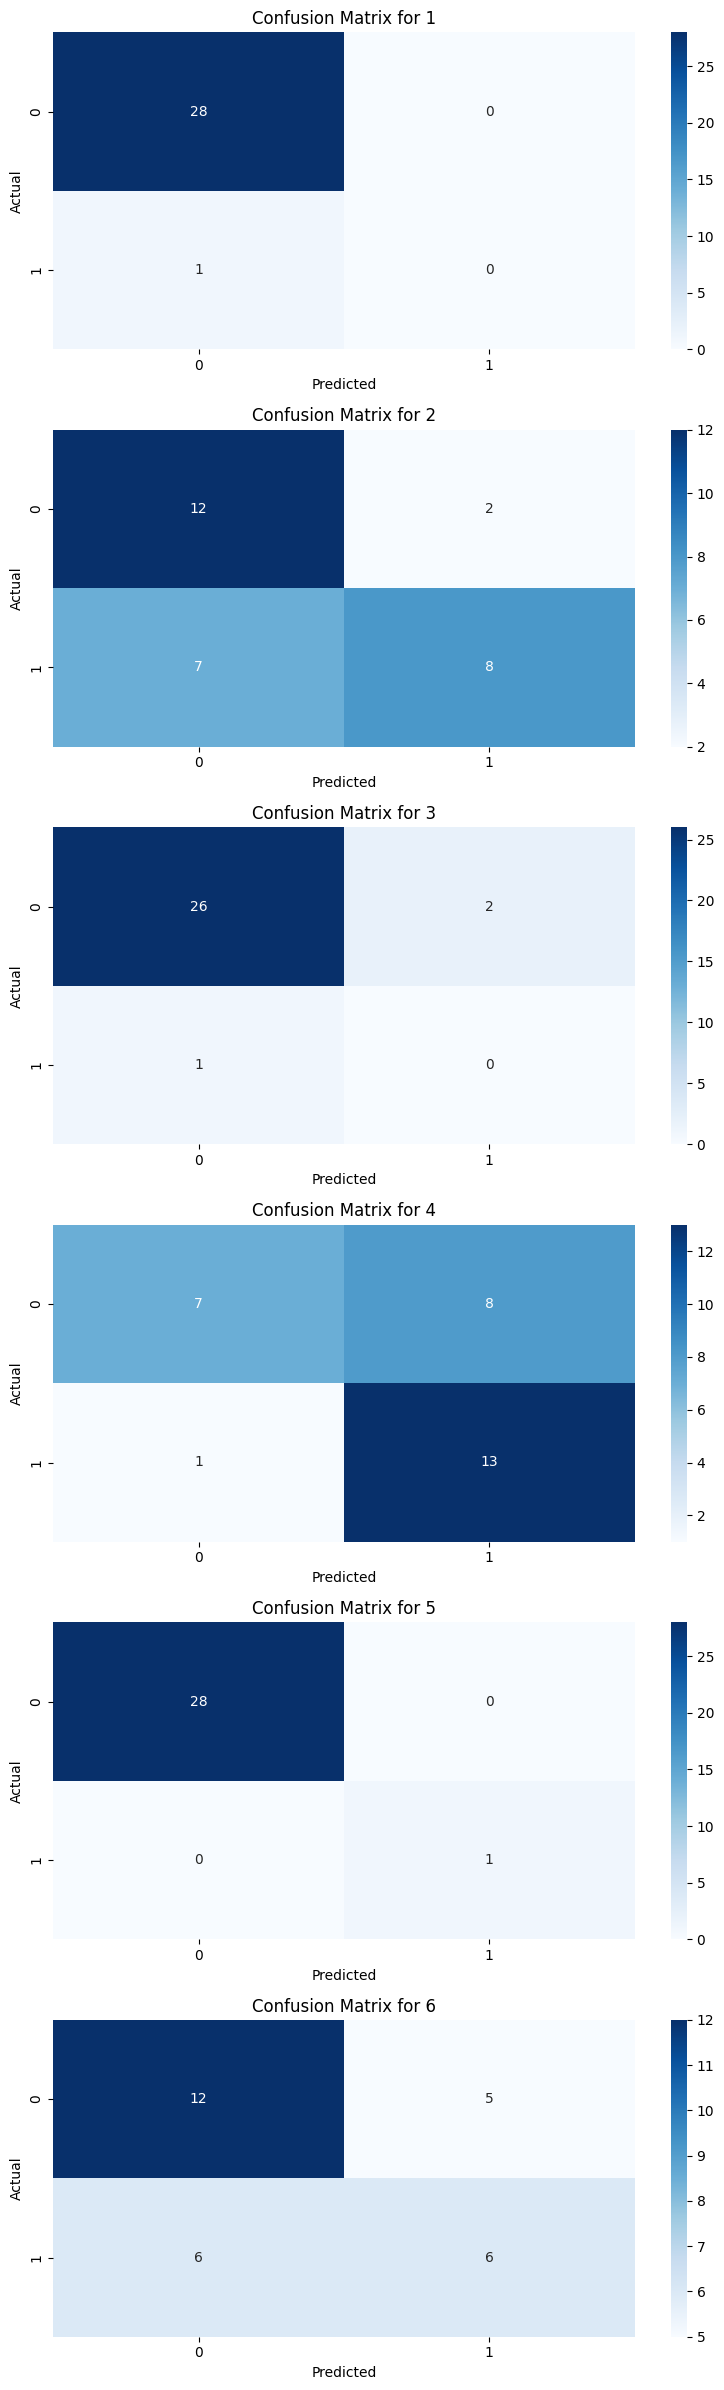

In [40]:

# Confusion Matrix per class
print("\n📉 Confusion Matrix for each class:")

cm = multilabel_confusion_matrix(y_test, y_pred)
# Plot confusion matrix for each class
fig, axes = plt.subplots(len(class_names), 1, figsize=(8, len(class_names) * 4))
for i, matrix in enumerate(cm):
    ax = axes[i] if len(class_names) > 1 else axes
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix for {class_names[i]}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

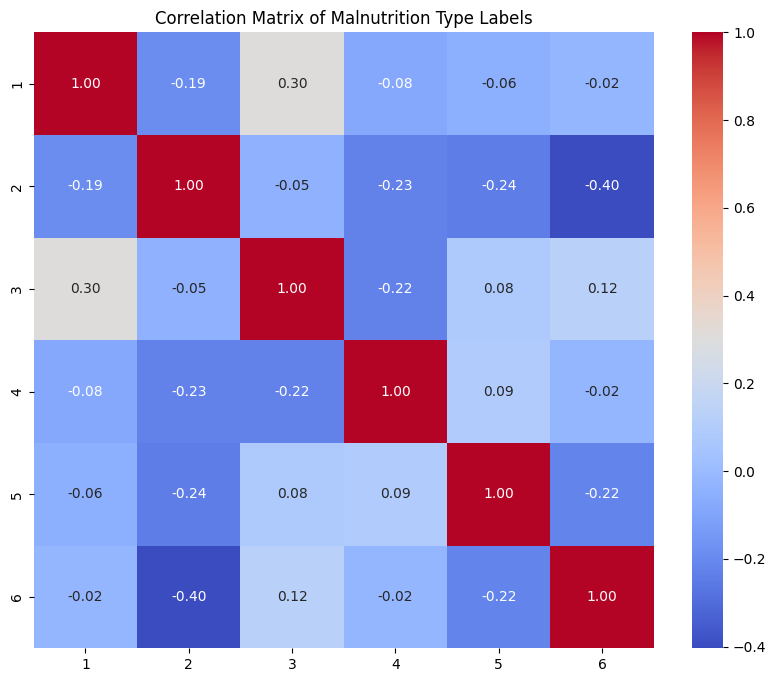

In [41]:
# Calculate correlation matrix for Malnutrition Type labels
correlation_matrix = np.corrcoef(y.T)

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=class_names, yticklabels=class_names)
plt.title("Correlation Matrix of Malnutrition Type Labels")
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Iterate over each label
for i, label_name in enumerate(class_names):
    print(f"\n🔍 Metrics for Label: {label_name}")
    
    # Extract the specific label for training and testing
    y_train_label = y_train[:, i]
    y_test_label = y_test[:, i]
    y_pred_label = y_pred[:, i]
    
    # Calculate confusion matrix
    cm_label = confusion_matrix(y_test_label, y_pred_label)
    print(f"Confusion Matrix:\n{cm_label}")
    
    # Calculate accuracy
    accuracy_label = accuracy_score(y_test_label, y_pred_label)
    print(f"Accuracy: {accuracy_label:.2f}")
    
    # Classification report
    report = classification_report(y_test_label, y_pred_label, zero_division=0)
    print(f"Classification Report:\n{report}")


🔍 Metrics for Label: 1
Confusion Matrix:
[[28  0]
 [ 1  0]]
Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       0.00      0.00      0.00         1

    accuracy                           0.97        29
   macro avg       0.48      0.50      0.49        29
weighted avg       0.93      0.97      0.95        29


🔍 Metrics for Label: 2
Confusion Matrix:
[[12  2]
 [ 7  8]]
Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73        14
           1       0.80      0.53      0.64        15

    accuracy                           0.69        29
   macro avg       0.72      0.70      0.68        29
weighted avg       0.72      0.69      0.68        29


🔍 Metrics for Label: 3
Confusion Matrix:
[[26  2]
 [ 1  0]]
Accuracy: 0.90
Classification Report:
              precision    recall  f1-score   sup

In [43]:
# Ignore classes 1 and 3
ignore_classes = ['1', '3']
ignore_indices = [i for i, cls in enumerate(class_names) if cls in ignore_classes]

# Filter out the ignored classes
y_train_filtered = np.delete(y_train_resampled, ignore_indices, axis=1)
y_test_filtered = np.delete(y_test, ignore_indices, axis=1)
filtered_class_names = np.delete(class_names, ignore_indices)

# Train the model again
pipeline.fit(X_train_resampled, y_train_filtered)

# Predict with the updated model
y_pred_filtered = pipeline.predict(X_test)

# Evaluate the updated model
print("\n📊 Classification Report (Filtered Classes):")
print(classification_report(y_test_filtered, y_pred_filtered, target_names=filtered_class_names))
accuracy = (y_test_filtered == y_pred_filtered).mean()
print(f"\n🔍 Model Accuracy: {accuracy:.2f}")


📊 Classification Report (Filtered Classes):
              precision    recall  f1-score   support

           2       0.75      0.40      0.52        15
           4       0.57      0.86      0.69        14
           5       1.00      1.00      1.00         1
           6       0.67      0.67      0.67        12

   micro avg       0.64      0.64      0.64        42
   macro avg       0.75      0.73      0.72        42
weighted avg       0.67      0.64      0.63        42
 samples avg       0.59      0.61      0.58        42


🔍 Model Accuracy: 0.74


C:\Users\Win 10\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:36:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [44]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score

# مدل‌های پایه
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)
xgb_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

# ترکیب مدل‌ها با VotingClassifier
base_ensemble_model = VotingClassifier(
    estimators=[('RandomForest', rf_model), ('GradientBoosting', gb_model), ('XGBoost', xgb_model)],
    voting='soft'  # استفاده از احتمال‌ها برای ترکیب
)

# Ignore classes 1 and 3
ignore_classes = ['1', '3']
ignore_indices = [i for i, cls in enumerate(class_names) if cls in ignore_classes]

# Filter out the ignored classes
y_train_filtered = np.delete(y_train_resampled, ignore_indices, axis=1)
y_test_filtered = np.delete(y_test, ignore_indices, axis=1)
filtered_class_names = np.delete(class_names, ignore_indices)

# Train the model again
ensemble_model = ClassifierChain(base_estimator=base_ensemble_model)
ensemble_model.fit(X_train_resampled, y_train_filtered)

# Predict with the updated model
y_pred_filtered = ensemble_model.predict(X_test)

# Evaluate the updated model
print("\n📊 Classification Report (Filtered Classes):")
print(classification_report(y_test_filtered, y_pred_filtered, target_names=filtered_class_names))

ValueError: Input contains NaN